### **EXPLORATORY DATA ANALYSIS**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Walmart.csv') #loading dataset
df.head() #dataset preview

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [21]:
df.dtypes #checking data types

Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Date column is currently loaded as type string. To support later analyses, we need to convert it to datetime.

In [ ]:
#converting date column to datetime type
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True) 
df.dtypes

Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [23]:
df.isnull().sum() #checking total amount of null values

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [24]:
df.duplicated().sum() #checking duplicated values

np.int64(0)

Preliminary exploration shows that we have no duplicates and no null values in our data.

In [25]:
print(df.shape) #checking for number of rows and columns
print(df['Store'].nunique()) #checking number of unique stores
print(df['Date'].min(), '-', df['Date'].max()) #checking date range

(6435, 8)
45
2010-02-05 00:00:00 - 2012-10-26 00:00:00


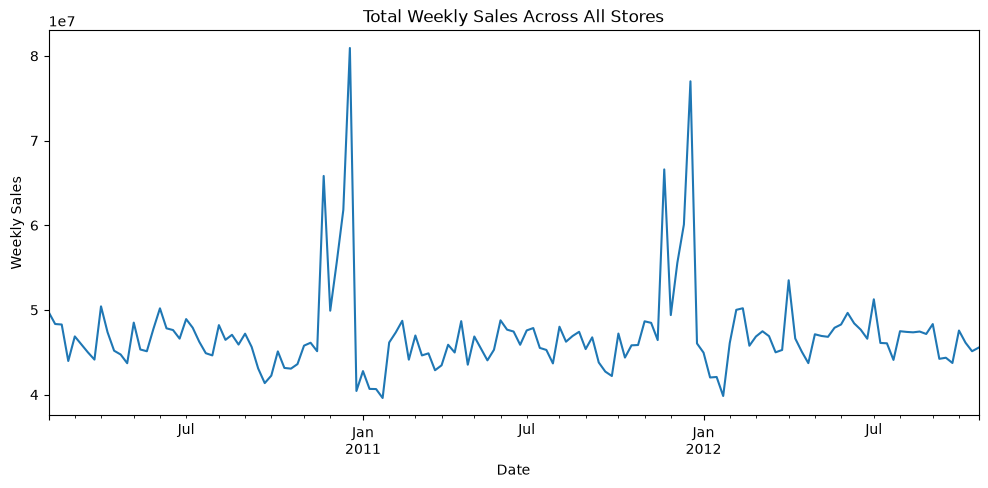

In [26]:
#checking sales trend over time
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
weekly_total.plot(figsize=(12,5), title='Total Weekly Sales Across All Stores')
plt.ylabel('Weekly Sales')
plt.show()

The plot of total weekly sales shows 2 distinctive spikes in sales around November to December of each year, which indicates the existence of a holiday effect that should be used as a control variable later on. To verify, we will compare the average sales between holidays and non-holidays.

In [30]:
#checking for holiday effect
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

Average sales across all stores are about 7.9% higher on holidays, confirming that we need to control for this variable in regressions.

In [ ]:
#checking for store-level variation: average weekly sales for each individual store
store_average = df.groupby('Store')['Weekly_Sales'].mean()
store_average.sort_values(ascending=False).head(10)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
Name: Weekly_Sales, dtype: float64

In [31]:
print(store_average.describe())

count    4.500000e+01
mean     1.046965e+06
std      5.466263e+05
min      2.598617e+05
25%      5.564039e+05
50%      9.667816e+05
75%      1.395901e+06
max      2.107677e+06
Name: Weekly_Sales, dtype: float64


There is a large disparity here: the smallest store only sells about 12% of the largest store's volume on average, and the standard deviation is pretty large relative to the median. This means we need to also control for store size in our analyses.